In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import math
from windrose import WindroseAxes
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates


## 1 Dataset 1: Long-Term Wind Data (10-min Resolution)

In [2]:
dir1 = Path("C:/Users/HP/Desktop/wind_measurement/Exercise2/long_term_jena_10min.csv")
dataset1 = pd.read_csv(dir1,index_col=0, parse_dates=True)
print(dataset1.info())
print()
print("=" * 64)
print()
print(dataset1.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420781 entries, 2017-01-01 00:10:00 to 2024-12-31 23:50:00
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   wind_speed_mps      420780 non-null  float64
 1   wind_direction_deg  420781 non-null  float64
 2   temperature_degC    420781 non-null  float64
dtypes: float64(3)
memory usage: 12.8 MB
None


wind_speed_mps        1
wind_direction_deg    0
temperature_degC      0
dtype: int64


In [3]:
dataset1.head()

,wind_speed_mps,wind_direction_deg,temperature_degC
datetime,,,
2017-01-01 00:10:00,0.78,184.0,-4.91
2017-01-01 00:20:00,1.52,202.6,-5.05
2017-01-01 00:30:00,0.98,227.4,-4.98
2017-01-01 00:40:00,1.16,212.5,-4.88
2017-01-01 00:50:00,1.50,222.1,-5.17


### Dataset1: Step 1: Exploratory Data Analysis (Scales)

In [4]:
# Confriming the time range of the dataset
print("Start date:", dataset1.index.min())
print("End date:", dataset1.index.max())
print(f"Dataset contains {len(dataset1)} records in total")

# Selecting one year of data for analysis
dataset1_2024 = dataset1.loc['2024'].copy()
print("Start date of 2024 data:", dataset1_2024.index.min())
print("End date of 2024 data:", dataset1_2024.index.max())
print("Number of records in 2024 data:", len(dataset1_2024))

# Checking for missing timestamps in the 2024 data
full_year = pd.date_range(start=dataset1_2024.index.min(), end=dataset1_2024.index.max(), freq='10min')
len(full_year) == len(dataset1_2024)

Start date: 2017-01-01 00:10:00
End date: 2024-12-31 23:50:00
Dataset contains 420781 records in total
Start date of 2024 data: 2024-01-01 00:00:00
End date of 2024 data: 2024-12-31 23:50:00
Number of records in 2024 data: 52704


True

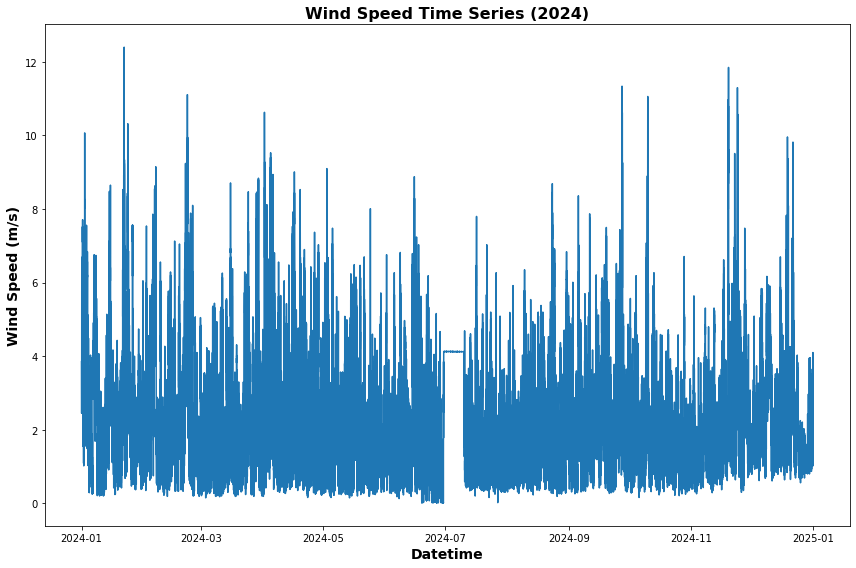

In [5]:
# Plotting the time series of the wind speed
plt.figure(figsize=(12,8))
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_mps"])
plt.title("Wind Speed Time Series (2024)", fontsize=16, fontweight="bold")
plt.xlabel("Datetime", fontsize=14, fontweight="bold")
plt.ylabel("Wind Speed (m/s)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
# Computing moving average and moving standard deviation of wind speed
window_size = 144  # 24 hours * 6 (10-minute intervals)
dataset1_2024["wind_speed_ma"] = dataset1_2024["wind_speed_mps"].rolling(window=window_size, center=True).mean()
dataset1_2024["wind_speed_mstd"] = dataset1_2024["wind_speed_mps"].rolling(window=window_size, center=True).std()
dataset1_2024["wind_speed_ma"]

datetime
2024-01-01 00:00:00   NaN
2024-01-01 00:10:00   NaN
2024-01-01 00:20:00   NaN
2024-01-01 00:30:00   NaN
2024-01-01 00:40:00   NaN
                       ..
2024-12-31 23:10:00   NaN
2024-12-31 23:20:00   NaN
2024-12-31 23:30:00   NaN
2024-12-31 23:40:00   NaN
2024-12-31 23:50:00   NaN
Name: wind_speed_ma, Length: 52704, dtype: float64

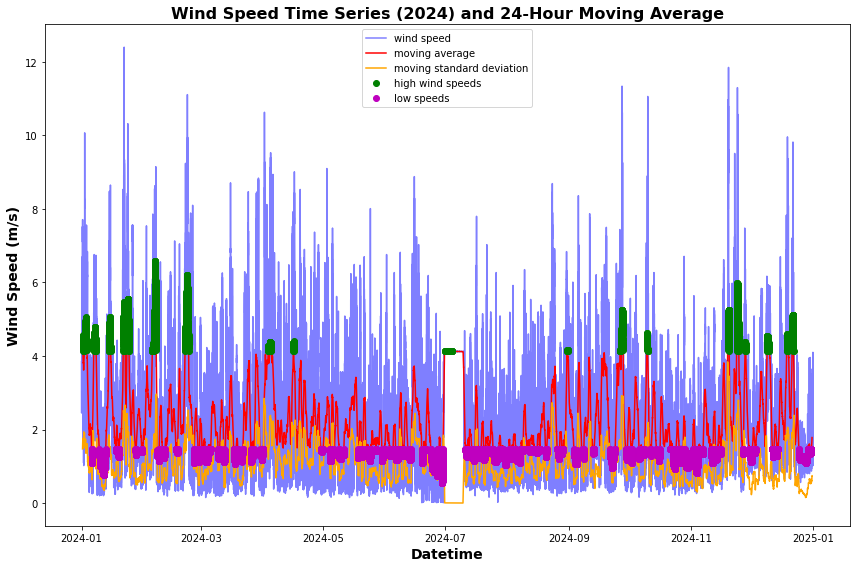

In [7]:
# Plotting the time series of the wind speed with moving average and standard deviation
# Plotting the time series of the wind speed
highs = dataset1_2024[dataset1_2024["wind_speed_ma"] > dataset1_2024["wind_speed_ma"].quantile(0.95)]
lows = dataset1_2024[dataset1_2024["wind_speed_ma"] < dataset1_2024["wind_speed_ma"].quantile(0.25)]
plt.figure(figsize=(12,8))
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_mps"], label="wind speed", color="blue", alpha=0.5)
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_ma"], label="moving average", color="red")
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_mstd"], label="moving standard deviation", color="orange")
plt.plot(highs.index, highs["wind_speed_ma"], "go", label="high wind speeds")
plt.plot(lows.index, lows["wind_speed_ma"], "mo", label="low speeds")
plt.title("Wind Speed Time Series (2024) and 24-Hour Moving Average", fontsize=16, fontweight="bold")
plt.xlabel("Datetime", fontsize=14, fontweight="bold")
plt.ylabel("Wind Speed (m/s)", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

### Dataset1 Step2: Statiscal Discription

----
#### Weibull Distribution

The Weibull probability density function is given by:

$$f(u) = \frac{k}{A} \left( \frac{u}{A} \right)^{k-1} \exp \left[ -\left( \frac{u}{A} \right)^k \right]$$

where:

*   **$u$** is the wind speed
*   **$k$** is the shape factor
*   **$A$** is the scale factor

---

### Key Parameters:

*   **The scale factor ($A$):** Tells us the general windiness of the site. A larger $A$ means the site has higher typical wind speeds.
*   **The shape factor ($k$):** Tells us how broad or narrow the wind-speed distribution is. 
    -   A **low $k$** means the wind is highly variable and skewed, with many low speeds and occasional high speeds. 
    -  A **high $k$** means the wind speeds are more concentrated around the mean.



**Statistical Properties of the Weibull Distribution**

The **mean wind speed** is:
$$\bar{u} = A \Gamma \left( 1 + \frac{1}{k} \right)$$

The **variance** is:
$$\sigma^2 = A^2 \left[ \Gamma \left( 1 + \frac{2}{k} \right) - \Gamma^2 \left( 1 + \frac{1}{k} \right) \right]$$

The **expected cubic wind speed**, which is critical for power calculations, is:
$$E[u^3] = A^3 \Gamma \left( 1 + \frac{3}{k} \right)$$

---

**Note:** This last expression is especially important because wind power depends on $u^3$, rather than a simple linear relationship with $u$.

----

**Source**: [1] R. Gasch and J. Twele, "Wind Power Plants: Fundamentals, Design, Construction and Operation," 2nd ed. Springer, 2012.

K: 1.52, loc: 0.00, scale: 2.47


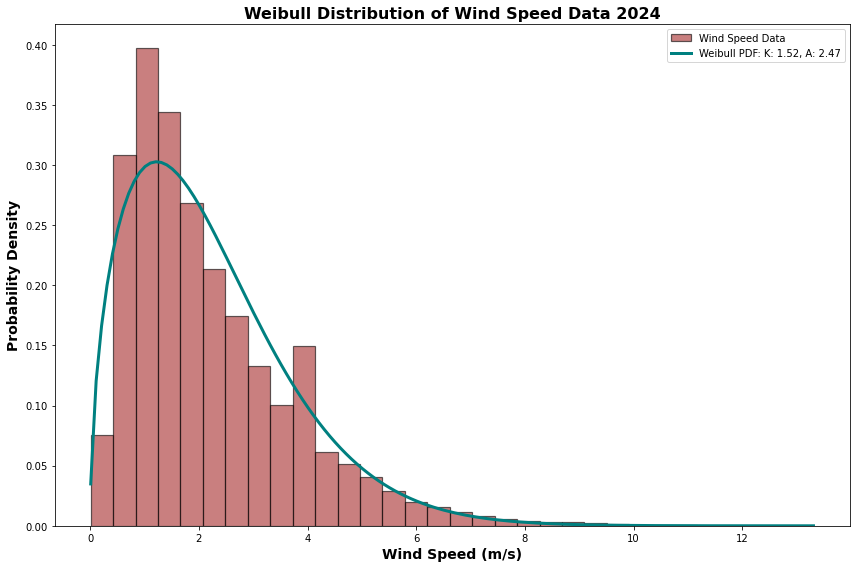

In [ ]:
# computing the weibull distribution parameters for the wind speed data
wind_speed_data = dataset1_2024["wind_speed_mps"].dropna()
min_speed = wind_speed_data.min()
max_speed = wind_speed_data.max()
speed_range = np.arange(min_speed, max_speed + 1, 0.1)
k, loc, scale = weibull_min.fit(wind_speed_data, floc=0)
print(f"K: {k:4.2f}, loc: {loc:.2f}, scale: {scale:.2f}")

# Computing the PDF of the Weibull distribution using the fitted parameters
weibull_pdf = weibull_min.pdf(speed_range, k, loc, scale)

# Plotting the histogram of the wind speed data and the fitted Weibull PDF
plt.figure(figsize=(12,8))
plt.hist(
    speed_range,
    bins=30, 
    density=True,
    alpha=0.6,
    histtype='bar',
    color="brown",
    edgecolor="black",
    linewidth=1.2,
    rwidth=1.0,
    label="Wind Speed Data"
    )
plt.plot(
    speed_range,
    weibull_pdf,
    color="teal",
    linewidth=3,
    label="Weibull PDF: K: {k:.2f}, A: {scale:.2f}".format(k=k, scale=scale)
    )
plt.xlabel("Wind Speed (m/s)", fontsize=14, fontweight="bold")
plt.ylabel("Probability Density", fontsize=14, fontweight="bold")
plt.title("Weibull Distribution of Wind Speed Data 2024", fontsize=16, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Using the fitted Weibull parameters to compute the mean and standard deviation of the wind speed

mean_wind_speed = scale * math.gamma(1 + 1/k)

wind_speed_variance = scale**2 * (
    math.gamma(1 + 2/k) - math.gamma(1 + 1/k)**2
)

wind_speed_standard_deviation = math.sqrt(wind_speed_variance)

print(mean_wind_speed)
print(wind_speed_standard_deviation)

2.227515149187492
1.4929411753267856


### Dataset1 STep 2: Statistical Description: Wind Direction

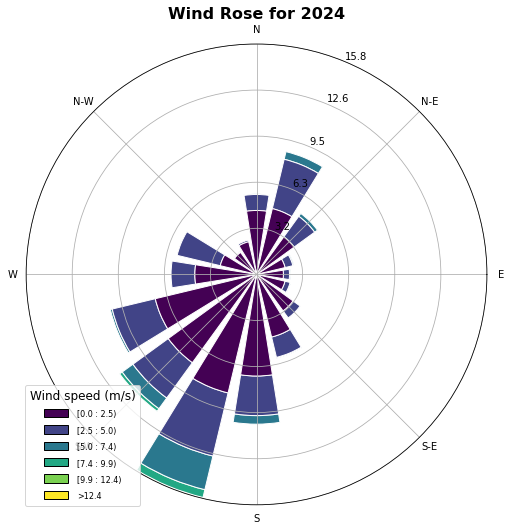

In [10]:
# Plotting windrose diagram for wind direction and speed
wind_direction = dataset1_2024["wind_direction_deg"].dropna()
wind_speed = dataset1_2024["wind_speed_mps"].dropna()

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    wind_direction,
    wind_speed,
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax.set_legend(title="Wind speed (m/s)", fontsize=12, title_fontsize=12)
ax.set_title("Wind Rose for 2024",fontsize=16, fontweight="bold")
plt.show()

In [11]:

direction_bins = np.arange(0, 361, 30)

dataset1_2024["direction_sector"] = pd.cut(
    dataset1_2024["wind_direction_deg"],
    bins=direction_bins,
    include_lowest=True,
    right=False
)

direction_frequency = (
    dataset1_2024["direction_sector"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

direction_frequency

direction_sector
[0, 30)       10.805374
[30, 60)       6.991043
[60, 90)       3.269698
[90, 120)      3.081828
[120, 150)     4.922575
[150, 180)     9.662973
[180, 210)    18.460604
[210, 240)    16.375057
[240, 270)    12.027478
[270, 300)     4.833384
[300, 330)     5.353348
[330, 360)     4.216639
Name: proportion, dtype: float64

### Dataset1 Step2 : Statistical Description: Energy Perspective

The goal is to determine whether the directions that occur most frequently are also the directions that contribute most to total wind energy. We compute the directional energy contribution using $u^3$, as wind power is proportional to the cube of the wind speed.

#### 1. Formula

For each direction sector $\theta$, compute:

$$E_{\theta} = 100 \cdot \frac{\sum_{i \in \theta} u_i^3}{\sum_{i} u_i^3}$$

**Where:**

*   **$E_{\theta}$**: Percentage energy contribution from direction sector $\theta$.
*   **$u_i$**: Wind speed at time step $i$.
*   **$u_i^3$**: Wind speed cubed.
*   **$\sum_{i \in \theta} u_i^3$**: Total energy proxy from one specific direction sector.
*   **$\sum_{i} u_i^3$**: Total energy proxy from all directions combined.

---

#### Why $u^3$?

We use the cube of the wind speed because the available wind power is defined as:

$$P = \frac{1}{2} \rho A C_p u^3$$

For a consistent site and turbine, the air density ($\rho$), swept area ($A$), and power coefficient ($C_p$) are treated as constants. Therefore, the directional comparison simplifies to the relationship with **$u^3$**.

In [12]:

# Remove missing wind speed or wind direction values
df_energy = dataset1_2024.dropna(subset=["wind_speed_mps", "wind_direction_deg"]).copy()


# Compute wind-speed cubed
df_energy["wind_speed_cubed"] = df_energy["wind_speed_mps"] ** 3

# Compute directional energy contribution in percentage
directional_energy = (
    df_energy.groupby("direction_sector", observed=False)["wind_speed_cubed"]
    .sum()
    .div(df_energy["wind_speed_cubed"].sum())
    .mul(100)
)

# Combine both results into one table
frequency_vs_energy = pd.DataFrame({
    "directional_frequency_percent": direction_frequency,
    "directional_energy_percent": directional_energy
})

frequency_vs_energy

,directional_frequency_percent,directional_energy_percent
direction_sector,,
"[0, 30)",10.805374,9.212542
"[30, 60)",6.991043,6.012007
"[60, 90)",3.269698,1.828490
"[90, 120)",3.081828,1.210476
"[120, 150)",4.922575,1.645748
"[150, 180)",9.662973,6.006939
"[180, 210)",18.460604,33.801068
"[210, 240)",16.375057,26.134416
"[240, 270)",12.027478,5.798742


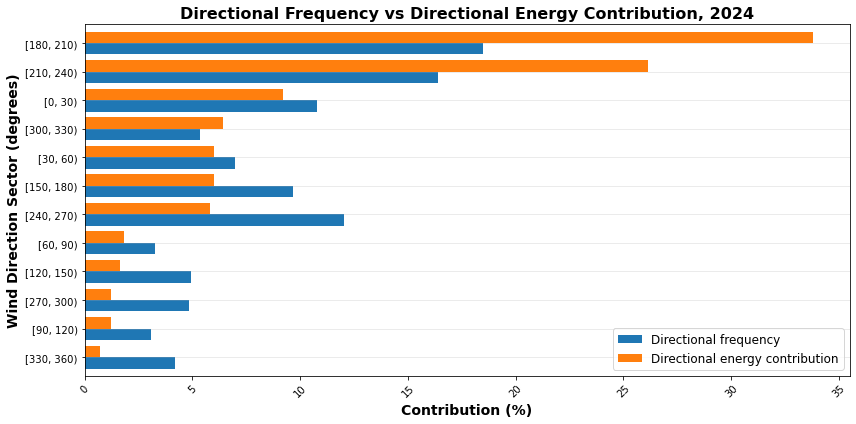

In [13]:
frequency_vs_energy = frequency_vs_energy.sort_values(
    by="directional_energy_percent",
    ascending=True
)

frequency_vs_energy.plot(
    kind="barh",
    figsize=(12, 6),
    width=0.8
)

plt.title("Directional Frequency vs Directional Energy Contribution, 2024", fontsize=16, fontweight="bold")
plt.ylabel("Wind Direction Sector (degrees)", fontsize=14, fontweight="bold")
plt.xlabel("Contribution (%)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(["Directional frequency", "Directional energy contribution"], fontsize=12)
plt.tight_layout()
plt.show()

### Dataset1 Step 3: Detrending (Scale Separation)

In [14]:
# first, we select the first 3 months of data for 2024
dataset1_2024_q1 = dataset1.loc['2024-01':'2024-03'].dropna().copy()
dataset1_2024_q1.tail()

,wind_speed_mps,wind_direction_deg,temperature_degC
datetime,,,
2024-03-31 23:10:00,0.19,254.40,12.18
2024-03-31 23:20:00,0.22,4.72,11.93
2024-03-31 23:30:00,0.90,185.20,11.67
2024-03-31 23:40:00,1.01,218.20,11.58
2024-03-31 23:50:00,0.46,210.70,11.37


In [15]:
# Employing additive seasonal decomposition to analyze the wind speed time series for the first quarter of 2024
decomposed = seasonal_decompose(dataset1_2024_q1["wind_speed_mps"], model="additive", period=144)

# retrieving the trend, seasonal, and residual components
trend = decomposed.trend
seasonal = decomposed.seasonal
residual = decomposed.resid
# computing the a 24-hour rolling standard deviation of the across components
trend_std = trend.rolling(window=144, center=True).std()
seasonal_std = seasonal.rolling(window=144, center=True).std()
residual_std = residual.rolling(window=144, center=True).std()

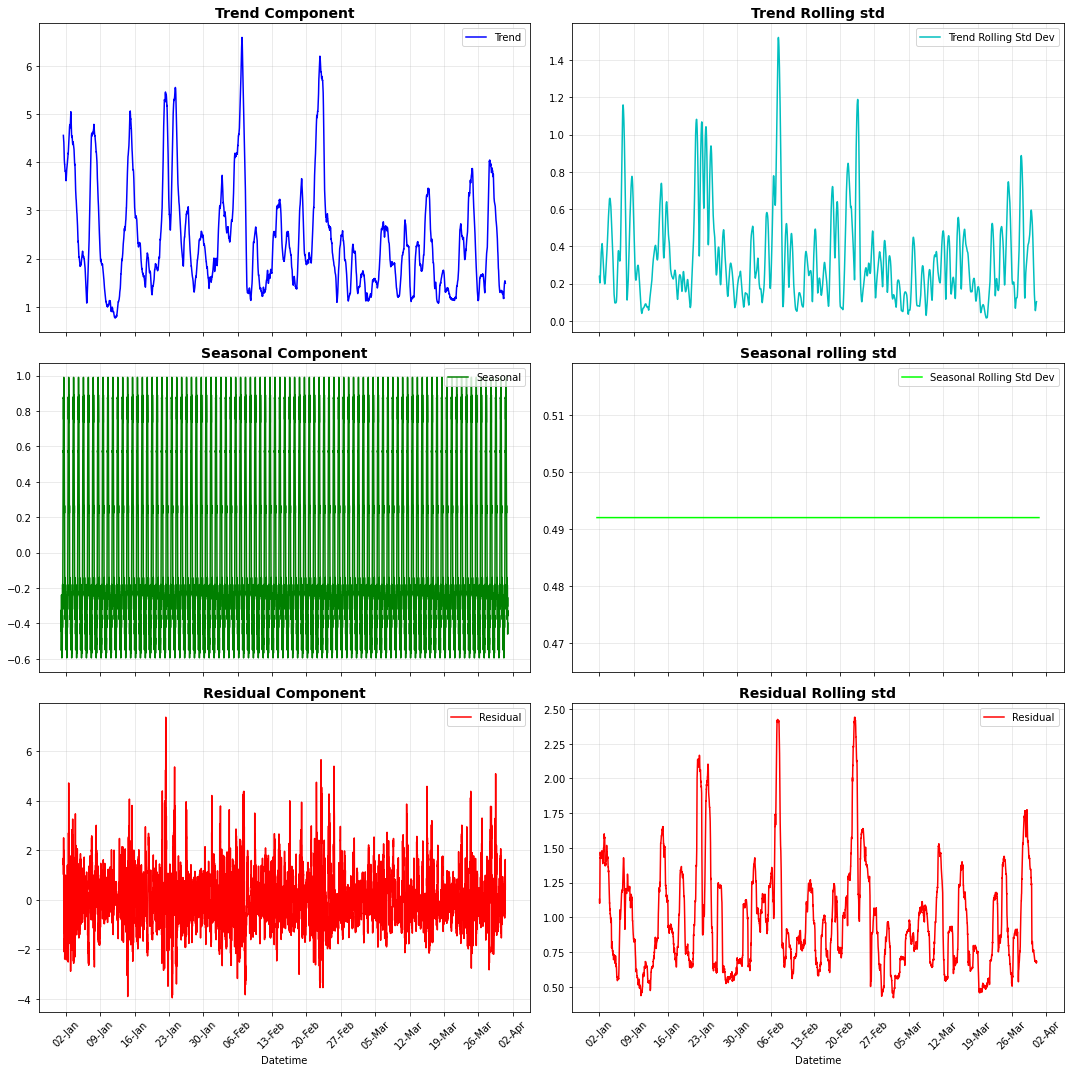

In [16]:
fig, ax = plt.subplots(3,2, figsize=(15, 15), sharex=True)
ax[0, 0].plot(trend, label="Trend", color="blue")
ax[0, 1].plot(trend_std, label="Trend Rolling Std Dev", color='c')
ax[0, 0].set_title("Trend Component", fontsize=14, fontweight="bold")
ax[0, 1].set_title("Trend Rolling std", fontsize=14, fontweight="bold")
ax[1, 0].plot(seasonal, label="Seasonal", color="green")
ax[1, 1].plot(seasonal_std, label="Seasonal Rolling Std Dev", color="lime")
ax[1, 0].set_title("Seasonal Component", fontsize=14, fontweight="bold")
ax[1, 1].set_title("Seasonal rolling std", fontsize=14, fontweight="bold")
ax[2, 0].plot(residual, label="Residual", color="red")
ax[2, 1].plot(residual_std, label="Residual", color="red")
ax[2, 0].set_title("Residual Component", fontsize=14, fontweight="bold")  
ax[2, 1].set_title("Residual Rolling std", fontsize=14, fontweight="bold")

# Hide x-tick labels for the first two rows only
for row in range(2):
    for col in range(2):
        ax[row, col].tick_params(axis="x", labelbottom=False)

# Keep y-ticks visible for all subplots
for axs in ax.flat:
    axs.tick_params(axis="y", labelleft=True)
    axs.grid(True, alpha=0.3)
    axs.legend()

# Format x-axis only on bottom row
locator = mdates.WeekdayLocator(interval=1)
formatter = mdates.DateFormatter("%d-%b")

for axs in ax[2, :]:
    axs.xaxis.set_major_locator(locator)
    axs.xaxis.set_major_formatter(formatter)
    axs.tick_params(axis="x", rotation=45)
    axs.set_xlabel("Datetime")

plt.tight_layout()
plt.show()

In [17]:
trend = dataset1_2024_q1["wind_speed_mps"].rolling(window=144, center=True, min_periods=144).mean()
detrended = dataset1_2024_q1["wind_speed_mps"] - trend
time_of_day = dataset1_2024_q1.index.hour + dataset1_2024_q1.index.minute // 10
seasonal_pattern = detrended.groupby(time_of_day).mean()

seasonal = pd.Series(
    data=time_of_day.map(seasonal_pattern),
    index=dataset1_2024_q1.index
)
seasonal_std = detrended.groupby(time_of_day).std()

residual = dataset1_2024_q1["wind_speed_mps"] - trend - seasonal

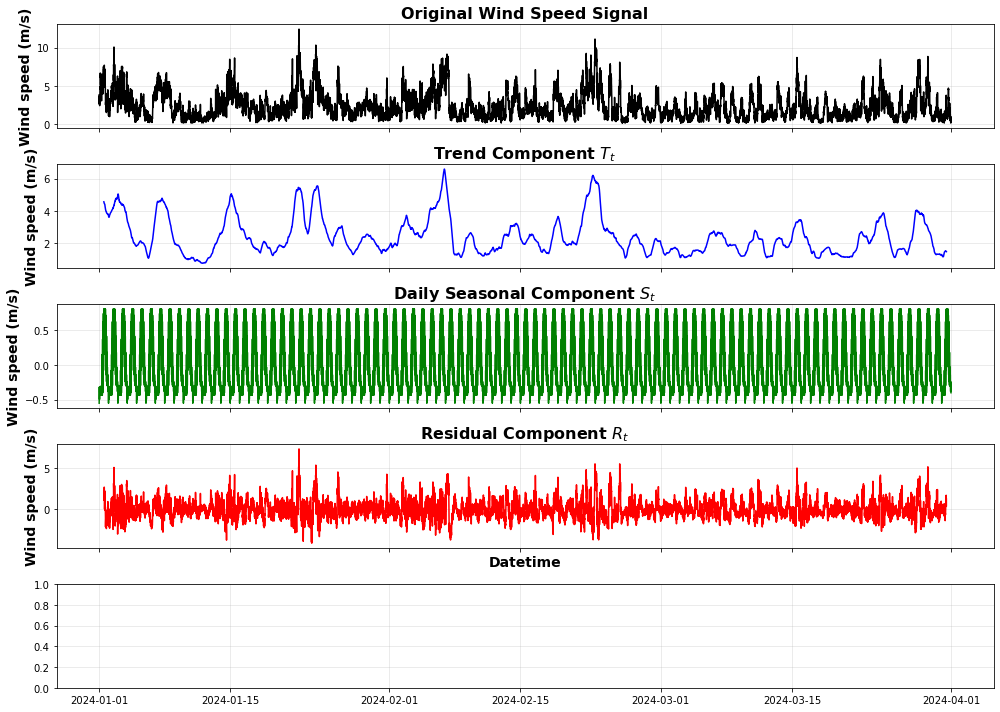

In [24]:
fig, ax = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

ax[0].plot(dataset1_2024_q1["wind_speed_mps"], color="black")
ax[0].set_title("Original Wind Speed Signal", fontsize=16, fontweight="bold")
ax[0].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")

ax[1].plot(trend, color="blue")
ax[1].set_title("Trend Component $T_t$", fontsize=16, fontweight="bold")
ax[1].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")

ax[2].plot(seasonal, color="green")
ax[2].set_title("Daily Seasonal Component $S_t$", fontsize=16, fontweight="bold")
ax[2].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")

ax[3].plot(residual, color="red")
ax[3].set_title("Residual Component $R_t$", fontsize=16, fontweight="bold")
ax[3].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")
ax[3].set_xlabel("Datetime", fontsize=14, fontweight="bold")


for axs in ax:
    axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:

trend_std = trend.rolling(
    window=144,
    center=True,
    min_periods=144
).std()

seasonal_std = seasonal.rolling(
    window=144,
    center=True,
    min_periods=144
).std()

residual_std = residual.rolling(
    window=144,
    center=True,
    min_periods=144
).std()

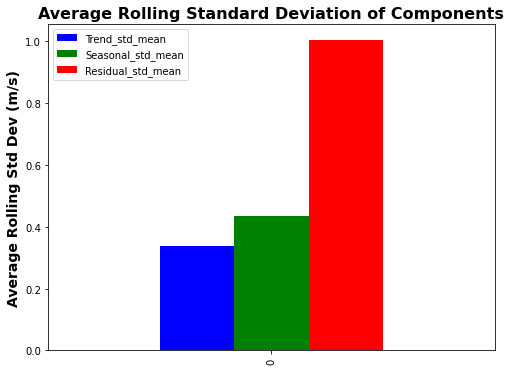

In [20]:
component_variability = pd.DataFrame({
    "Trend_std_mean": [trend_std.mean()],
    "Seasonal_std_mean": [seasonal_std.mean()],
    "Residual_std_mean": [residual_std.mean()]
})

component_variability.plot(
    kind="bar",
    figsize=(8, 6),
    color=["blue", "green", "red"],
    legend=True
)
plt.title("Average Rolling Standard Deviation of Components", fontsize=16, fontweight="bold")
plt.ylabel("Average Rolling Std Dev (m/s)", fontsize=14, fontweight="bold")
plt.show()

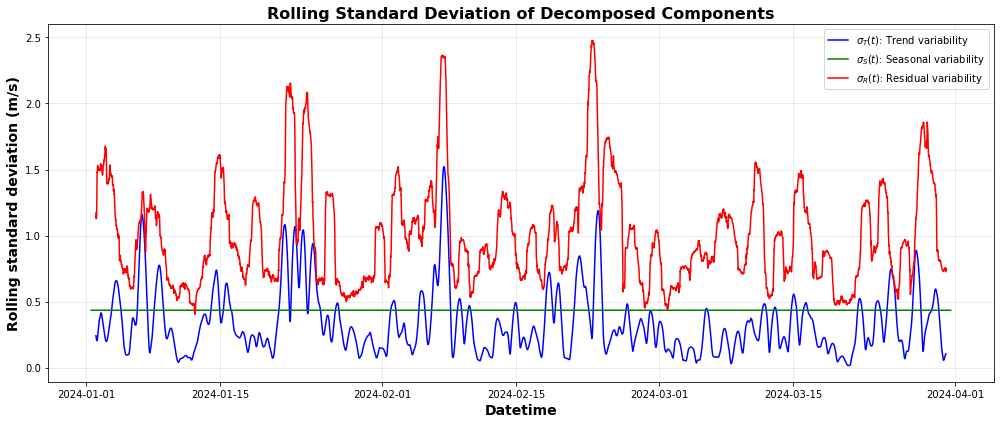

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(trend_std, label=r"$\sigma_T(t)$: Trend variability", color="blue")
plt.plot(seasonal_std, label=r"$\sigma_S(t)$: Seasonal variability", color="green")
plt.plot(residual_std, label=r"$\sigma_R(t)$: Residual variability", color="red")

plt.title("Rolling Standard Deviation of Decomposed Components", fontsize=16, fontweight="bold")
plt.xlabel("Datetime", fontsize=14, fontweight="bold")
plt.ylabel("Rolling standard deviation (m/s)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Emanuele Merveille Guehi - Topic 2 Dataset2 step 7**

In [7]:
# STEP 7: Microscale variability
# Goal:
# We want to look at a short 10–20 minute period and see how the wind fluctuates
# around its local average value.
# ---------------------------------------------------------
# 1. Loading the data
# ---------------------------------------------------------

csv_path = Path("data") / "one_day_hamburg_multiheight_20hz.csv"

df = pd.read_csv(csv_path, parse_dates=["datetime"])
df = df.set_index("datetime")

# Show first rows to confirm the data loaded correctly
df.head()

,wind_speed_50m_mps,wind_direction_50m_deg,wind_speed_110m_mps,wind_direction_110m_deg,wind_speed_175m_mps,wind_direction_175m_deg,wind_speed_250m_mps,wind_direction_250m_deg
datetime,,,,,,,,
2023-02-01 00:00:00.000,10.05,263.5,18.10,272.6,13.86,271.5,15.38,278.9
2023-02-01 00:00:00.050,9.67,260.8,18.18,273.6,13.95,274.2,15.44,279.4
2023-02-01 00:00:00.100,9.35,260.6,18.44,273.0,13.78,275.7,15.46,278.9
2023-02-01 00:00:00.150,9.42,258.3,18.32,273.5,13.75,275.1,15.68,277.6
2023-02-01 00:00:00.200,9.35,254.6,18.13,272.4,13.67,274.4,15.53,277.4


In [8]:
# ---------------------------------------------------------
# 2. Checking the available columns
# ---------------------------------------------------------

print("Dataset size:", df.shape)
print("\nColumns:")
for col in df.columns:
    print(col)

print("\nStart time:", df.index.min())
print("End time:", df.index.max())

Dataset size: (1728001, 8)

Columns:
wind_speed_50m_mps
wind_direction_50m_deg
wind_speed_110m_mps
wind_direction_110m_deg
wind_speed_175m_mps
wind_direction_175m_deg
wind_speed_250m_mps
wind_direction_250m_deg

Start time: 2023-02-01 00:00:00
End time: 2023-02-02 00:00:00


In [9]:
# ---------------------------------------------------------
# 3. Select height and 20-minute period
# ---------------------------------------------------------

height = 110
u_col = f"wind_speed_{height}m_mps"

start_time = "2023-02-01 20:35:00"
end_time = "2023-02-01 20:55:00"

segment = df.loc[start_time:end_time, [u_col]].dropna().copy()

print("Selected height:", height, "m")
print("Selected period:", start_time, "to", end_time)
print("Number of samples in selected period:", len(segment))
print("Expected sampling frequency: 20 Hz")

Selected height: 110 m
Selected period: 2023-02-01 20:35:00 to 2023-02-01 20:55:00
Number of samples in selected period: 23826
Expected sampling frequency: 20 Hz


C:\Users\emanu\AppData\Local\Temp\ipykernel_22368\3908933999.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\emanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


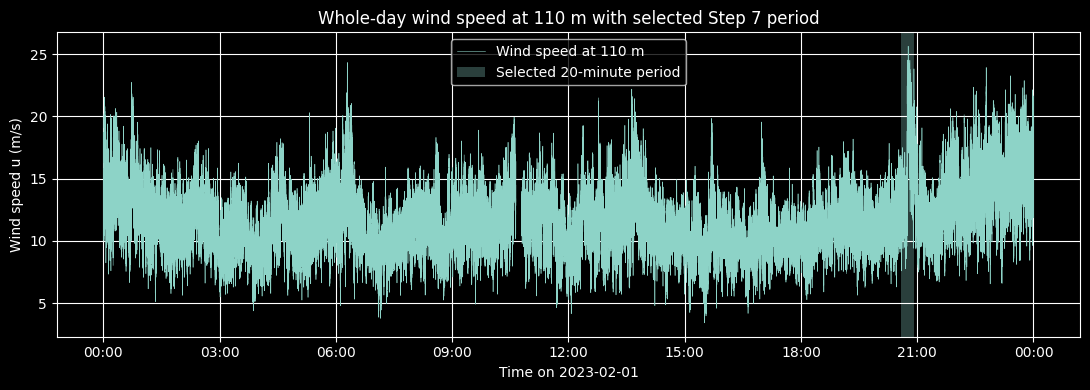

In [10]:
# ---------------------------------------------------------
# 4. Context plot: whole-day wind speed with selected period highlighted
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df.index, df[u_col], linewidth=0.4, label=f"Wind speed at {height} m")

ax.axvspan(
    pd.to_datetime(start_time),
    pd.to_datetime(end_time),
    alpha=0.3,
    label="Selected 20-minute period"
)

ax.set_title(f"Whole-day wind speed at {height} m with selected Step 7 period")
ax.set_ylabel("Wind speed u (m/s)")
ax.set_xlabel("Time on 2023-02-01")
ax.legend()
ax.grid(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------
# 5. Compute 30-second moving average and turbulent fluctuation
# ---------------------------------------------------------

# 30-second moving average:
# This represents the local/background wind speed.
segment["u_bar_30s"] = segment[u_col].rolling(
    "30s", center=True, min_periods=1
).mean()

# Turbulent fluctuation:
# This is the fast part of the wind signal.
segment["u_prime"] = segment[u_col] - segment["u_bar_30s"]

segment.head()

,wind_speed_110m_mps,u_bar_30s,u_prime
datetime,,,
2023-02-01 20:35:00.000,11.71,13.263300,-1.553300
2023-02-01 20:35:00.050,11.42,13.259635,-1.839635
2023-02-01 20:35:00.100,11.53,13.256954,-1.726954
2023-02-01 20:35:00.150,11.69,13.253894,-1.563894
2023-02-01 20:35:00.200,11.70,13.252270,-1.552270


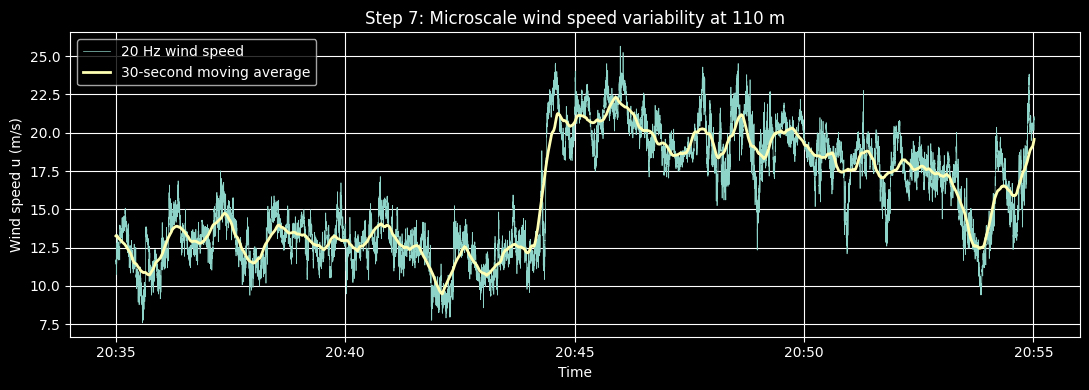

In [12]:
# ---------------------------------------------------------
# 6. Plot raw wind speed and 30-second moving average
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    segment.index,
    segment[u_col],
    linewidth=0.5,
    label="20 Hz wind speed"
)

ax.plot(
    segment.index,
    segment["u_bar_30s"],
    linewidth=2,
    label="30-second moving average"
)

ax.set_title(f"Step 7: Microscale wind speed variability at {height} m")
ax.set_ylabel("Wind speed u (m/s)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

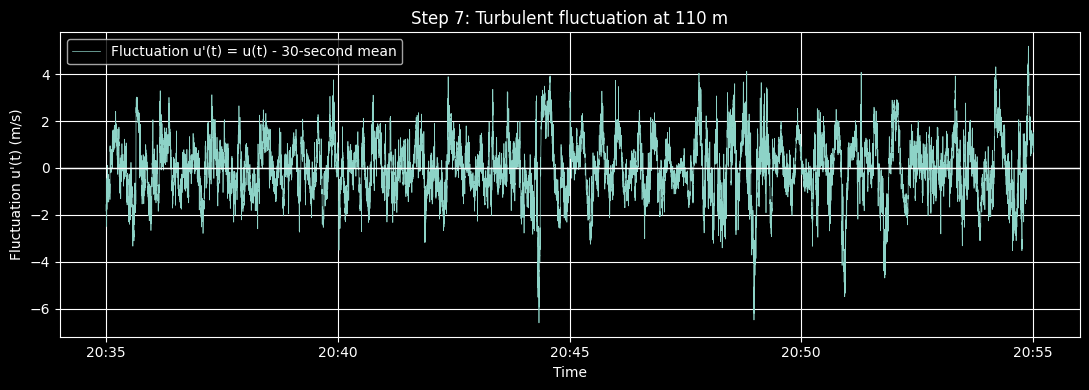

In [13]:
# ---------------------------------------------------------
# 7. Plot fluctuation u'(t)
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    segment.index,
    segment["u_prime"],
    linewidth=0.5,
    label="Fluctuation u'(t) = u(t) - 30-second mean"
)

ax.axhline(0, linewidth=1)

ax.set_title(f"Step 7: Turbulent fluctuation at {height} m")
ax.set_ylabel("Fluctuation u'(t) (m/s)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

In [14]:
# ---------------------------------------------------------
# 8. Basic statistics for report
# ---------------------------------------------------------

mean_u = segment[u_col].mean()
std_u = segment[u_col].std()
min_u = segment[u_col].min()
max_u = segment[u_col].max()
std_u_prime = segment["u_prime"].std()

print("STEP 7 STATISTICS")
print("-----------------")
print(f"Height: {height} m")
print(f"Period: {start_time} to {end_time}")
print(f"Mean wind speed: {mean_u:.2f} m/s")
print(f"Standard deviation of wind speed: {std_u:.2f} m/s")
print(f"Minimum wind speed: {min_u:.2f} m/s")
print(f"Maximum wind speed: {max_u:.2f} m/s")
print(f"Standard deviation of fluctuation u': {std_u_prime:.2f} m/s")

STEP 7 STATISTICS
-----------------
Height: 110 m
Period: 2023-02-01 20:35:00 to 2023-02-01 20:55:00
Mean wind speed: 15.81 m/s
Standard deviation of wind speed: 3.75 m/s
Minimum wind speed: 7.59 m/s
Maximum wind speed: 25.65 m/s
Standard deviation of fluctuation u': 1.24 m/s
